# Reconnaissance des personnages d'enfants

In [1]:
#%pip install matplotlib
#%pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression

## 1. Chargement et exploration des données

In [2]:
df = pd.read_csv("/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/Metadata/BoW_1000_personnages.csv")

In [3]:
df.head()

,title,Gender,author_gender,type,avoir,dire,voir,faire,vouloir,pouvoir,...,lunette,gens,façon,propre,ménage,manteau,troupe,futur,daigner,geste
0,1833_Girardin-Delphine-de_Contes-d-une-vieille...,0,0,1,0.031686,0.021546,0.024081,0.017744,0.031686,0.027883,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1,1,1,0.020779,0.020779,0.036364,0.015584,0.024675,0.024675,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1833_Girardin-Delphine-de_Contes-d-une-vieille...,0,1,1,0.026415,0.011321,0.015094,0.011321,0.020755,0.024528,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1,1,1,0.018908,0.023109,0.025210,0.012605,0.018908,0.016807,...,0.002101,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1833_Girardin-Delphine-de_Contes-d-une-vieille...,0,1,2,0.025822,0.016432,0.016432,0.032864,0.009390,0.009390,...,0.000000,0.002347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# suppression de la colonne des titres et des celles du genre
df.drop(columns=["title", "Gender","author_gender"], axis=1, inplace=True)

In [5]:
df.head()

,type,avoir,dire,voir,faire,vouloir,pouvoir,aller,petit,savoir,...,lunette,gens,façon,propre,ménage,manteau,troupe,futur,daigner,geste
0,1,0.031686,0.021546,0.024081,0.017744,0.031686,0.027883,0.015209,0.002535,0.020279,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.020779,0.020779,0.036364,0.015584,0.024675,0.024675,0.010390,0.020779,0.009091,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.026415,0.011321,0.015094,0.011321,0.020755,0.024528,0.013208,0.011321,0.018868,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.018908,0.023109,0.025210,0.012605,0.018908,0.016807,0.025210,0.018908,0.006303,...,0.002101,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,0.025822,0.016432,0.016432,0.032864,0.009390,0.009390,0.014085,0.011737,0.009390,...,0.000000,0.002347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# affichage du nombre d'occurrences de chaque type de personnage
# 0 = adult, 1= enfant, 2= animal, 3 = pupée, 4 = object, 5 = other
df["type"].value_counts()

type
0    281
1    279
5     31
2     18
3      3
4      1
Name: count, dtype: int64

In [7]:
# creation d'un nouveau dataframe ne contenant que les types 0 (adult) et 1 (enfant)
df_new = df[df["type"].isin([0,1])]

In [8]:
df_new["type"].value_counts()

type
0    281
1    279
Name: count, dtype: int64

In [10]:
#df_new = df_new.dropna(inplace=False)

## 2. Entraînement SVC

In [9]:
# séparation des features et de la target
X = df_new.drop(columns=["type"])
Y = df_new["type"]

In [10]:
X.head()

,avoir,dire,voir,faire,vouloir,pouvoir,aller,petit,savoir,aimer,...,lunette,gens,façon,propre,ménage,manteau,troupe,futur,daigner,geste
0,0.031686,0.021546,0.024081,0.017744,0.031686,0.027883,0.015209,0.002535,0.020279,0.019011,...,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.0
1,0.020779,0.020779,0.036364,0.015584,0.024675,0.024675,0.010390,0.020779,0.009091,0.009091,...,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.0
2,0.026415,0.011321,0.015094,0.011321,0.020755,0.024528,0.013208,0.011321,0.018868,0.007547,...,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.0
3,0.018908,0.023109,0.025210,0.012605,0.018908,0.016807,0.025210,0.018908,0.006303,0.018908,...,0.002101,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.0
5,0.027829,0.009972,0.021104,0.012755,0.011596,0.022495,0.006725,0.006725,0.004406,0.006494,...,0.000000,0.0,0.0,0.0,0.00116,0.0,0.0,0.0,0.000232,0.0


In [11]:
Y.head()

0    1
1    1
2    1
3    1
5    1
Name: type, dtype: int64

Accuratezza media: 0.818


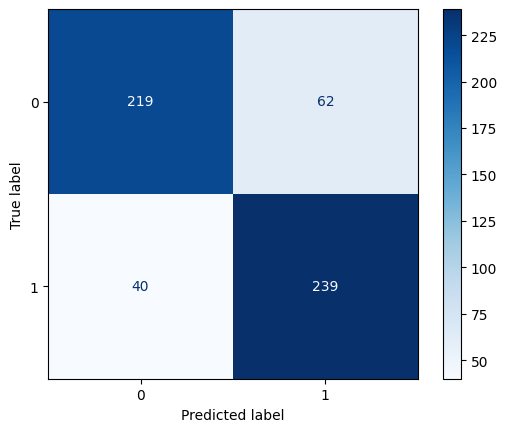

In [14]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Creazione della Pipeline: prima scala i dati, poi applica SVM
clf_pipeline = make_pipeline(StandardScaler(), svm.SVC(kernel='sigmoid', C=1.0))

# 1. Calcolo dell'accuratezza media
scores = cross_val_score(clf_pipeline, X, Y, cv=5, n_jobs=-1) # n_jobs=-1 usa tutti i core
print(f"Accuratezza media: {scores.mean():.3f}")

# 2. Ottenere predizioni per la Matrice di Confusione
Y_pred = cross_val_predict(clf_pipeline, X, Y, cv=5, n_jobs=-1)
cm = confusion_matrix(Y,Y_pred)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(Y, Y_pred)
recall = recall_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Precision: 0.794
Recall: 0.857
F1-score: 0.824


## Permutation Feature Importance

Idea:

- Mischi una feature alla volta
- misuri quanto crolla l’accuracy
- più crolla → più la feature è importante

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

# Dividiamo in train e test per velocizzare l'importanza (calcolarla su tutto il dataset è lento)
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Addestriamo il modello sul set di train
clf_pipeline.fit(X_train, y_train)

# Calcolo importanza (Ottimizzato)
result = permutation_importance(
    clf_pipeline, X_val, y_val, 
    n_repeats=3,         # Ridotto per velocità
    random_state=42, 
    n_jobs=-1            # Parallelizzazione massimizzata
)

# Organizziamo i risultati in un DataFrame per visualizzare le top 20
feature_importance = pd.Series(result.importances_mean, index=X.columns)
print("Top 10 Feature Importanti:")
print(feature_importance.sort_values(ascending=False).head(10))

Top 10 Feature Importanti:
homme        0.017857
fauteuil     0.014881
payer        0.014881
femme        0.014881
voiture      0.014881
éclater      0.011905
cou          0.011905
prière       0.011905
cher         0.011905
entraîner    0.011905
dtype: float64


/var/folders/dy/_vzc_bl12fv1jxcs5db4wmwh0000gn/T/ipykernel_15354/4147637179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


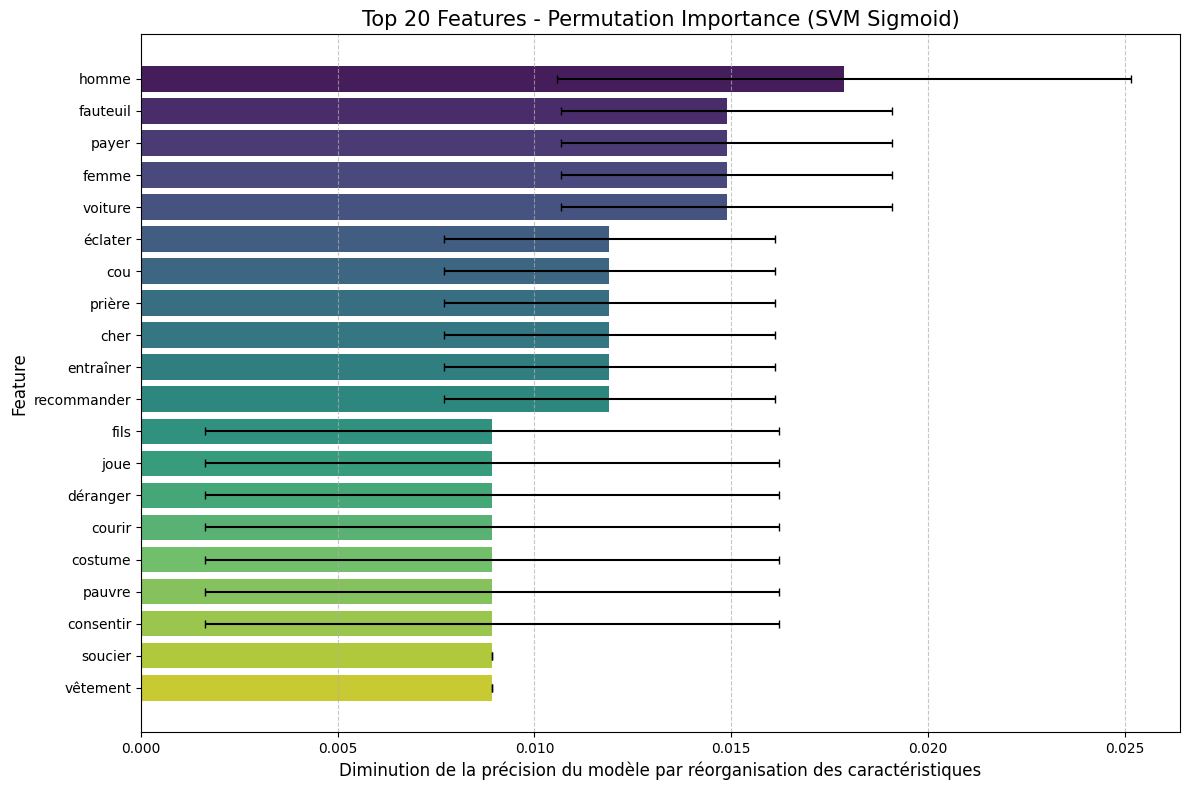

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo un DataFrame con i risultati per facilitare il plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean,
    'Std_Dev': result.importances_std
}).sort_values(by='Importance', ascending=False)

# 2. Selezioniamo solo le top 20 feature
top_n = 20
top_importance = importance_df.head(top_n)

# 3. Creazione del grafico
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis'
)

# Aggiungiamo le barre di errore (deviazione standard tra i repeat)
plt.errorbar(
    x=top_importance['Importance'], 
    y=range(top_n), 
    xerr=top_importance['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Top {top_n} Features - Permutation Importance (SVM Sigmoid)', fontsize=15)
plt.xlabel('Diminution de la précision du modèle par réorganisation des caractéristiques', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Random Forest

Accuratezza media (Random Forest): 0.827


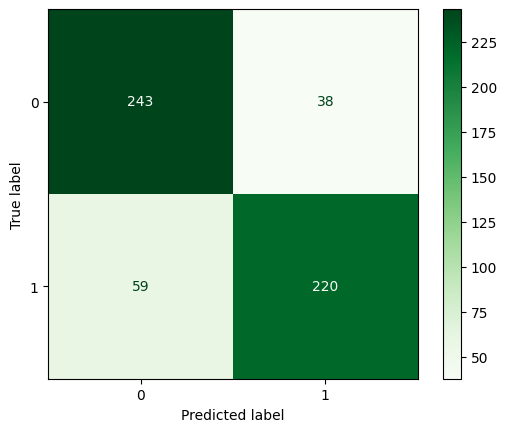

In [16]:
from sklearn.ensemble import RandomForestClassifier # Cambiato qui
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Creazione della Pipeline
# Nota: RandomForest non richiede scaling, ma lo teniamo per coerenza con la tua struttura
clf_pipeline = make_pipeline(
    StandardScaler(), 
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
)

# 2. Calcolo dell'accuratezza media con Cross-Validation
scores = cross_val_score(clf_pipeline, X, Y, cv=5, n_jobs=-1)
print(f"Accuratezza media (Random Forest): {scores.mean():.3f}")

# 3. Ottenere predizioni per la Matrice di Confusione
Y_pred = cross_val_predict(clf_pipeline, X, Y, cv=5, n_jobs=-1)
cm = confusion_matrix(Y, Y_pred)

# Visualizzazione Matrice di Confusione
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens') # Cambiato colore in verde, tipico dei Forest

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(Y, Y_pred)
recall = recall_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Precision: 0.853
Recall: 0.789
F1-score: 0.819


In [18]:
# --- Analisi dell'Importanza delle Feature ---

# Suddivisione Train/Validation
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Addestramento
clf_pipeline.fit(X_train, y_train)

# Calcolo Permutation Importance
# Rispetto alla SVM, qui vedrai probabilmente risultati molto più chiari 
# perché gli alberi gestiscono meglio le relazioni non lineari
result = permutation_importance(
    clf_pipeline, X_val, y_val, 
    n_repeats=5,         
    random_state=42, 
    n_jobs=-1            
)

# Visualizzazione Risultati
feature_importance = pd.Series(result.importances_mean, index=X.columns)
print("\nTop 10 Feature Importanti (Random Forest):")
print(feature_importance.sort_values(ascending=False).head(10))


Top 10 Feature Importanti (Random Forest):
petit        0.041071
jeune        0.014286
toucher      0.010714
dormir       0.010714
mentir       0.008929
garçon       0.008929
tourner      0.008929
compagnon    0.008929
lancer       0.008929
charger      0.008929
dtype: float64


/var/folders/dy/_vzc_bl12fv1jxcs5db4wmwh0000gn/T/ipykernel_15354/4147637179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


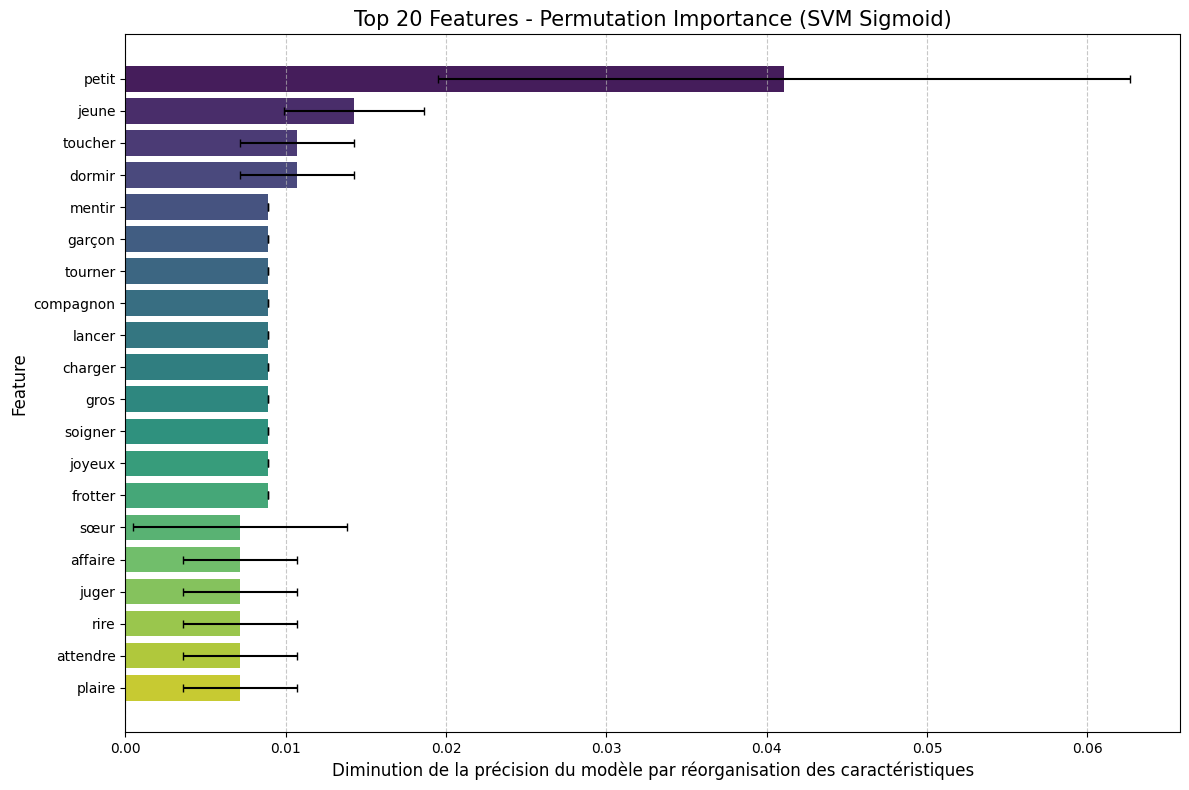

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo un DataFrame con i risultati per facilitare il plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean,
    'Std_Dev': result.importances_std
}).sort_values(by='Importance', ascending=False)

# 2. Selezioniamo solo le top 20 feature
top_n = 20
top_importance = importance_df.head(top_n)

# 3. Creazione del grafico
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis'
)

# Aggiungiamo le barre di errore (deviazione standard tra i repeat)
plt.errorbar(
    x=top_importance['Importance'], 
    y=range(top_n), 
    xerr=top_importance['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Top {top_n} Features - Permutation Importance (SVM Sigmoid)', fontsize=15)
plt.xlabel('Diminution de la précision du modèle par réorganisation des caractéristiques', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Accuratezza media (Logistic Regression): 0.786

Top 10 Feature Importanti (Logistic Regression):
éveiller    0.014286
sauter      0.014286
femme       0.012500
tâche       0.012500
plaindre    0.010714
voler       0.010714
daigner     0.010714
bras        0.010714
faible      0.010714
gai         0.010714
dtype: float64


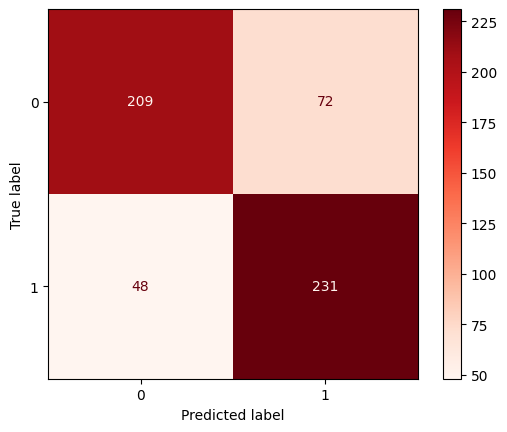

In [20]:
from sklearn.linear_model import LogisticRegression # Import specifico
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Creazione della Pipeline
# Per la Logistic Regression, lo StandardScaler è CRUCIALE per la convergenza
clf_pipeline = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, random_state=42)
)

# 2. Calcolo dell'accuratezza media
scores = cross_val_score(clf_pipeline, X, Y, cv=5, n_jobs=-1)
print(f"Accuratezza media (Logistic Regression): {scores.mean():.3f}")

# 3. Matrice di Confusione
Y_pred = cross_val_predict(clf_pipeline, X, Y, cv=5, n_jobs=-1)
cm = confusion_matrix(Y, Y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds') # Colore rosso per distinguere il modello lineare

# --- Analisi dell'Importanza delle Feature ---
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
clf_pipeline.fit(X_train, y_train)

# Calcolo Permutation Importance
result = permutation_importance(
    clf_pipeline, X_val, y_val, 
    n_repeats=5,         
    random_state=42, 
    n_jobs=-1            
)

feature_importance = pd.Series(result.importances_mean, index=X.columns)
print("\nTop 10 Feature Importanti (Logistic Regression):")
print(feature_importance.sort_values(ascending=False).head(10))

/var/folders/dy/_vzc_bl12fv1jxcs5db4wmwh0000gn/T/ipykernel_15354/4147637179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


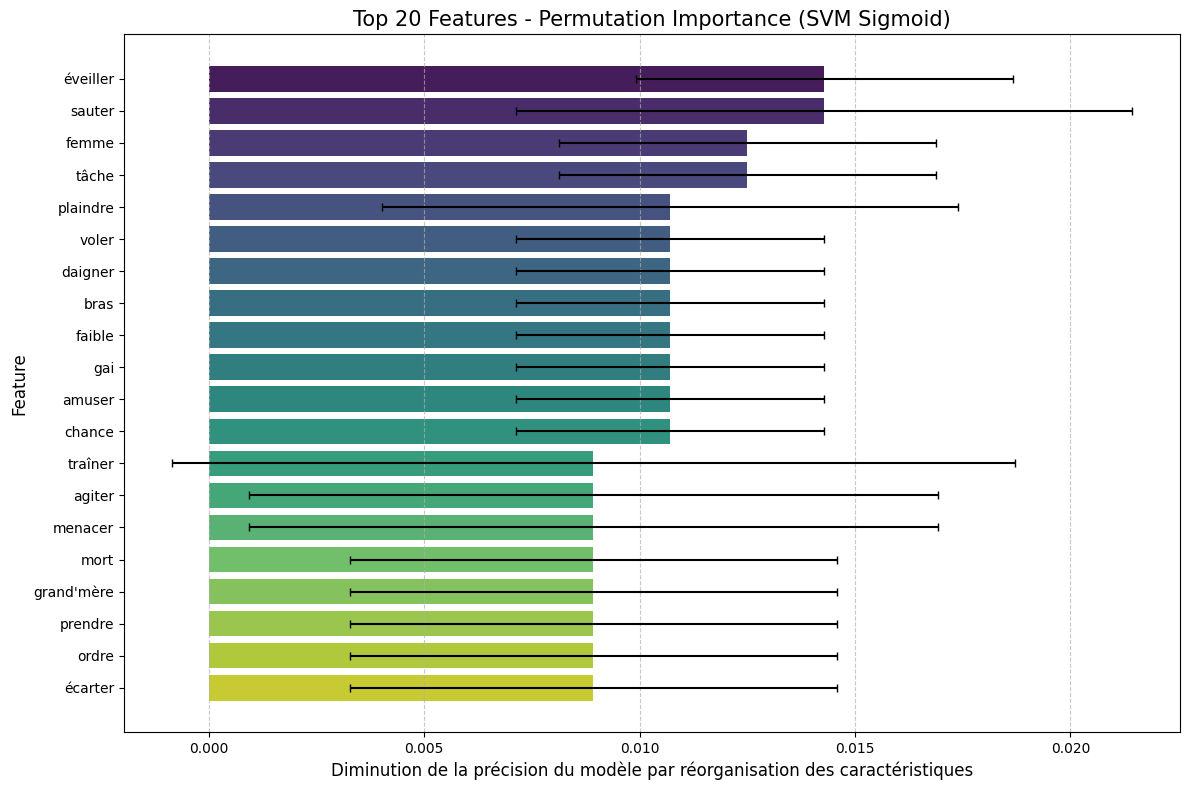

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo un DataFrame con i risultati per facilitare il plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean,
    'Std_Dev': result.importances_std
}).sort_values(by='Importance', ascending=False)

# 2. Selezioniamo solo le top 20 feature
top_n = 20
top_importance = importance_df.head(top_n)

# 3. Creazione del grafico
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_importance, 
    palette='viridis'
)

# Aggiungiamo le barre di errore (deviazione standard tra i repeat)
plt.errorbar(
    x=top_importance['Importance'], 
    y=range(top_n), 
    xerr=top_importance['Std_Dev'], 
    fmt='none', 
    c='black', 
    capsize=3
)

plt.title(f'Top {top_n} Features - Permutation Importance (SVM Sigmoid)', fontsize=15)
plt.xlabel('Diminution de la précision du modèle par réorganisation des caractéristiques', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
# Dopo aver addestrato la pipeline della Logistic Regression
model = clf_pipeline.named_steps['logisticregression']
features = X.columns

# Estraiamo i pesi
weights = pd.DataFrame({'word': features, 'coefficient': model.coef_[0]})
weights = weights.sort_values(by='coefficient', ascending=False)

print("Parole più 'Adulte' (Coefficienti positivi):")
print(weights.head(10))

print("\nParole più 'Bambine' (Coefficienti negativi):")
print(weights.tail(10))

Parole più 'Adulte' (Coefficienti positivi):
        word  coefficient
7      petit     0.614901
14      mère     0.436628
128  content     0.333546
892   chérir     0.292530
258   sauter     0.292522
104   parent     0.287228
48      sœur     0.278338
707   défaut     0.263150
13      père     0.262517
245   épaule     0.255057

Parole più 'Bambine' (Coefficienti negativi):
          word  coefficient
57          m.    -0.229673
32      donner    -0.237200
29         bon    -0.245534
197  compagnon    -0.266582
195      homme    -0.281781
388        foi    -0.287898
28      enfant    -0.307656
377      habit    -0.318668
95        mari    -0.330780
41       fille    -0.394999
